# <font color='green' size=6> **Решающие деревья**



In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine, fetch_california_housing

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text, export_graphviz

import graphviz

from sklearn.metrics import (accuracy_score, mean_squared_error,
                             r2_score,classification_report)
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions


In [2]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)

In [3]:
# фиксируем для вопроизводимости
my_random_state = 12345

## <font size=6 color='green'> **Классификация с помощью решающих деревьев**

In [4]:
# Загрузка датасета Вин
wine = load_wine()
# X, y = wine.data, wine.target

X = pd.DataFrame(data=wine.data, columns=wine.feature_names)
y = wine.target
print(f"X shape: {X.shape}, Y shape: {y.shape}")
X.head()

X shape: (178, 13), Y shape: (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


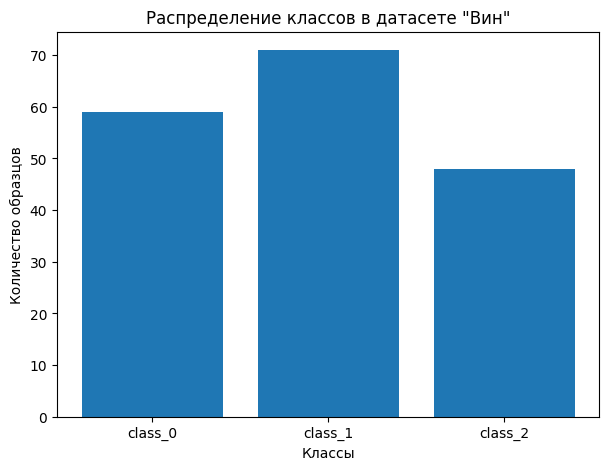

In [5]:
# Посчитаем количество образцов для каждого класса
unique_classes, counts = np.unique(y, return_counts=True)

# Отобразим бар-плот
plt.bar(unique_classes, counts, tick_label=wine.target_names)
plt.xlabel('Классы')
plt.ylabel('Количество образцов')
plt.title('Распределение классов в датасете "Вин"')
plt.show()

Описание признаков (характеристик):

- Alcohol (Алкоголь): содержание алкоголя в вине (% по объему)
- Malic Acid (Яблочная кислота): содержание яблочной кислоты в вине (г/л)
- Ash (Зольность): содержание минералов, представленное зольностью (% по массе)
- Alcalinity of Ash (Щелочность золы): общая щелочность золы (г/л)
- Magnesium (Магний): содержание магния в вине (мг/л)
Total Phenols (Общие фенолы): общее содержание фенолов в вине (г/л)
- Flavanoids (Флавоноиды): содержание флавоноидов в вине (г/л)
- Nonflavanoid Phenols (Нефлавоноидные фенолы): содержание нефлавоноидных фенолов в вине (г/л)
- Proanthocyanins (Проантоцианидины): содержание проантоцианидинов в вине (г/л)
- Color Intensity (Интенсивность цвета): интенсивность цвета виноградного сока (от 1 до 10)
- Hue (Оттенок): оттенок вина, измеренный в градусах от 0 до 360
- OD280/OD315 of diluted wines (OD280/OD315 разбавленных вин): соотношение оптической плотности разбавленных вин при длине волны 280/315 нм
- Proline (Пролин): содержание пролина в вине (мг/л)

**Целевая переменная (классы):**

- Class_0: сорт 1
- Class_1: сорт 2
- Class_2: сорт 3


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=my_random_state
)

dt_classifier = DecisionTreeClassifier(max_depth=2, random_state=my_random_state)
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2, random_state=12345)

In [7]:
# Получение предсказанных меток классов на тестовой выборке
y_pred_test = dt_classifier.predict(X_test)
y_pred_train = dt_classifier.predict(X_train)
# Вычисление точности
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_train, accuracy_test

(0.9112903225806451, 0.7407407407407407)

#<font size=6 color='green'> **Подбор гиперпараметров**

In [8]:
dt_classifier = DecisionTreeClassifier()

In [9]:
# Определение сетки параметров для GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [10]:
# Создаем объект GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, n_jobs=-1)


In [11]:
# Обучаем GridSearch на обучающей выборке
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [12]:
# Выводим наилучшие параметры и точность на трейн выборке
print("Наилучшие параметры: ", grid_search.best_params_)
print("Точность на трейн выборке: ", grid_search.best_score_)

Наилучшие параметры:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Точность на трейн выборке:  0.9436666666666665


In [13]:
# Преобразуем результаты GridSearchCV в DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006315,0.000900,0.003444,0.000835,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.88,0.92,0.80,0.88,0.916667,0.879333,0.043226,64
1,0.005826,0.000879,0.003127,0.000526,gini,None,1,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.84,0.92,0.80,0.88,0.916667,0.871333,0.045976,71
2,0.005180,0.001079,0.003382,0.001189,gini,None,1,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.92,0.92,0.64,0.88,0.958333,0.863667,0.114545,75
3,0.004825,0.001296,0.003772,0.001488,gini,None,2,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.88,0.92,0.76,0.88,0.958333,0.879667,0.066537,59
4,0.005017,0.001462,0.002851,0.000468,gini,None,2,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.84,0.92,0.80,0.88,0.958333,0.879667,0.056099,59


In [14]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


In [15]:
dt_classifier = DecisionTreeClassifier(**grid_search.best_params_)

# Выполняем кросс-валидацию с k фолдами (k-fold cross-validation)
# cv=k означает, что данные разделятся на k частей, и k раз происходит обучение и оценка модели
# scoring='accuracy' означает, что оценка производится на основе точности классификации
k = 5
scores = cross_val_score(dt_classifier, X, y, cv=k, scoring='accuracy')

# Выводим результаты кросс-валидации
print("Scores:", scores)
print("Mean Accuracy:", np.mean(scores))


Scores: [0.91666667 0.83333333 0.94444444 0.94285714 0.88571429]
Mean Accuracy: 0.9046031746031747


In [16]:
# Вычисление среднего значения
mean_value = np.mean(scores)

# Вычисление дисперсии
variance = np.var(scores)

print("Среднее значение:", mean_value)
print("Дисперсия:", variance)

Среднее значение: 0.9046031746031747
Дисперсия: 0.0017264802217183152


# <font size=6 color='green'> **Feature importance**

In [17]:
dt_classifier = DecisionTreeClassifier(max_depth=2, random_state=my_random_state)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=12345)

In [18]:
dt_classifier.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.47124817, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.52875183])

In [19]:
pd.DataFrame(
    {"feature": X.columns, "importance": dt_classifier.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

,feature,importance
0,proline,0.528752
1,flavanoids,0.471248
2,ash,0.000000
3,malic_acid,0.000000
4,alcohol,0.000000
5,magnesium,0.000000
6,alcalinity_of_ash,0.000000
7,nonflavanoid_phenols,0.000000
8,total_phenols,0.000000
9,proanthocyanins,0.000000


А как рассчитвается feature_importances ?

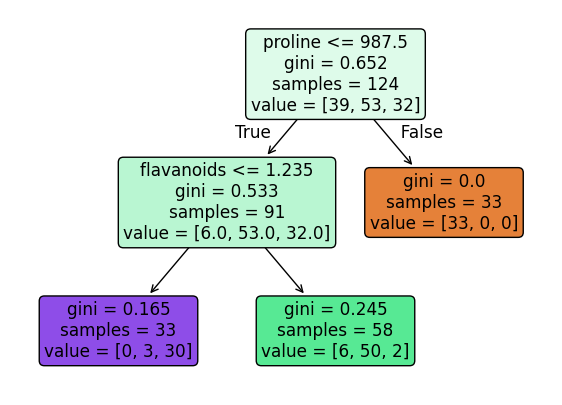

In [20]:
plot_tree(dt_classifier, feature_names=X.columns, filled=True, rounded=True)
plt.show()

In [21]:
# считаем прирост информации для первого разбиения
f1 = 0.652*1 - 91/124*0.533 - 33/124*0
f1

0.2608467741935484

In [22]:
# считаем прирост информации для второго разбиения
f2 = 0.533*91/124 - 0.165*33/124 - 0.245*58/124
f2

0.23264516129032256

In [23]:
# нормируем значение f1
f1/(f1+f2)

0.5285735296520845

In [24]:
# нормируем значение f2
f2/(f1+f2)

0.4714264703479156

# <font size=6 color='green'> **Влияет ли стандартизация (масштабирование) признаков на результат работы решающего дерева?**

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
sc = StandardScaler()
X_train_scaled = pd.DataFrame(
    sc.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    sc.transform(X_test), columns=X_test.columns, index=X_test.index
)
X_train_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
110,-1.878979,1.161398,-1.958366,0.013210,0.669727,1.439035,0.606807,-0.963773,3.401659,-0.876875,-0.976929,0.303212,-0.549673
98,-0.755256,-1.088679,-0.914546,-0.274160,-0.719249,1.976553,1.811617,-0.963773,0.641106,-0.147922,0.282224,0.241802,-0.252457
92,-0.360101,-0.701025,-0.318077,0.358054,-1.304080,-1.406651,-0.546516,1.770592,0.082221,-0.808535,-0.065129,-0.848225,-0.752872
95,-0.631770,-0.709453,-0.541753,-0.130475,4.690444,0.363998,0.287583,-0.320393,2.893582,-1.013553,0.803253,0.026867,0.587633
15,0.800667,-0.465062,1.322213,-0.647741,1.035246,0.917326,0.946625,-0.481238,-0.188753,1.127746,1.324281,0.410679,1.718873


In [27]:
dt = DecisionTreeClassifier(max_depth=3, random_state=my_random_state)
dt.fit(X_train, y_train)
print(
    f"accuracy_score: {accuracy_score(y_test, dt.predict(X_test)):.10f}"
)

accuracy_score: 0.8333333333


In [28]:
pd.DataFrame(
    {"feature": X.columns, "importance": dt.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

,feature,importance
0,proline,0.519616
1,flavanoids,0.403939
2,hue,0.076445
3,malic_acid,0.000000
4,alcohol,0.000000
5,magnesium,0.000000
6,alcalinity_of_ash,0.000000
7,ash,0.000000
8,total_phenols,0.000000
9,proanthocyanins,0.000000


In [29]:

dt_sc = DecisionTreeClassifier(max_depth=3, random_state=my_random_state)
dt_sc.fit(X_train_scaled, y_train)
print(
    f"accuracy_score: {accuracy_score(y_test, dt_sc.predict(X_test_scaled)):.10f}"
)

accuracy_score: 0.8333333333


In [30]:
pd.DataFrame(
    {"feature": X.columns, "importance": dt_sc.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

,feature,importance
0,proline,0.519616
1,flavanoids,0.403939
2,hue,0.076445
3,malic_acid,0.000000
4,alcohol,0.000000
5,magnesium,0.000000
6,alcalinity_of_ash,0.000000
7,ash,0.000000
8,total_phenols,0.000000
9,proanthocyanins,0.000000


# <font size=6 color='green'> **Визуализация**

In [ ]:
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=my_random_state)
dt_classifier.fit(X_train, y_train)

In [ ]:
text_representation = export_text(dt_classifier)
print(text_representation)

In [ ]:
# Визуализация дерева решений с помощью Graphviz
dot_data = export_graphviz(dt_classifier, out_file=None,
                           feature_names=wine.feature_names,
                           class_names=wine.target_names,
                           filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("wine_tree")  # Сохраняем дерево в файл "wine_tree.pdf"
graph.view()  # Открываем дерево во внешнем просмотрщике (например, Graphviz или pdf-reader)


In [ ]:
# второй способ отрисовать деревья с помощью plot_tree
plot_tree(dt_classifier, feature_names=X.columns, filled=True, rounded=True)
plt.show()

# <font size=6 color='green'> **Регрессионное дерево**

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedHouseValue')

In [ ]:
X['target'] = y
X.to_csv('california_housing.csv')

In [ ]:
plt.title("House price distribution")
plt.xlabel("price")
plt.ylabel("# samples")
plt.hist(y, bins=20)
plt.show()

In [ ]:
X.head()

In [ ]:
X.describe()

In [ ]:
# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Создание и обучение модели дерева решений с поиском по сетке
param_grid = {
    'max_depth': [ 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.01, 0.02, 0.03]
}

regressor = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(regressor, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_regressor = grid_search.best_estimator_


In [ ]:
# Оценка модели с оптимальными параметрами
y_pred = best_regressor.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)


mse_train = mean_squared_error(y_train, best_regressor.predict(X_train))
r2_train = r2_score(y_train, best_regressor.predict(X_train))

print("Best Parameters:", best_params)
print("Mean Squared Error (MSE) TEST:", mse_test, "\nMean Squared Error (MSE) TRAIN:", mse_train)
print("R-squared (R2) test:", r2_test, "\nR-squared (R2) train:", r2_train )


In [20]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 123,
 '123']

In [ ]:
# Шаг 5: Визуализация дерева решений
plt.figure(figsize=(10, 8))
plot_tree(best_regressor, filled=True, feature_names=data.feature_names)
plt.show()

In [ ]:
# Сохранение результатов кросс-валидации
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.head()